In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "ecommerce_sales_analytics_5000.csv",
    parse_dates=["order_date"]
)

Text(0, 0.5, 'Revenue')

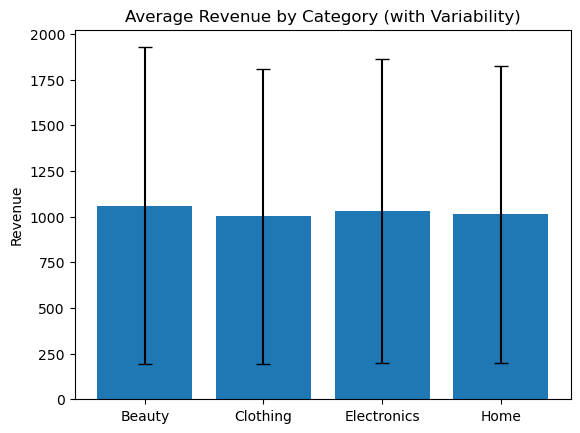

In [2]:
stats = df.groupby("product_category")["revenue"].agg(["mean", "std"])

fig, ax = plt.subplots()

ax.bar(
    stats.index,
    stats["mean"],
    yerr=stats["std"],
    capsize=5
)

ax.set_title("Average Revenue by Category (with Variability)")
ax.set_ylabel("Revenue")

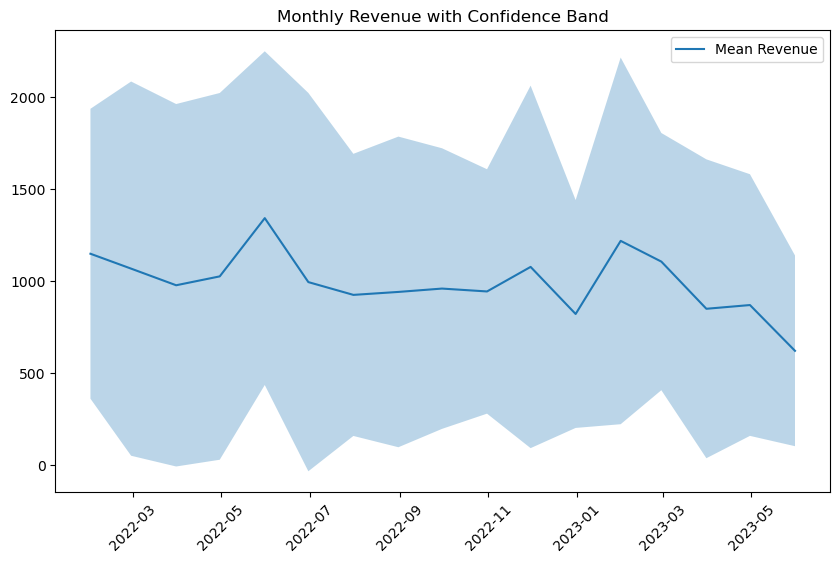

In [3]:
df = df.head(n=500)

monthly = (
    df
    .set_index("order_date")["revenue"]
    .resample("ME")
    .agg(["mean", "std"])
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(monthly.index,
        monthly["mean"],
        label="Mean Revenue")

ax.fill_between(
    monthly.index,
    monthly["mean"] - monthly["std"],
    monthly["mean"] + monthly["std"],
    alpha=0.3
)

ax.tick_params(axis="x", rotation=45)

ax.set_title("Monthly Revenue with Confidence Band")
ax.legend()